In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import scipy
import matplotlib.ticker as tck
import scipy.signal
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

font = {'size'   : 12}
matplotlib.rc('font', **font)
plt.rcParams['axes.labelsize'] = 14

# Plot overpotentials
##### The electrolyte overpotentials (electrolyte concentration and ohmic contributions) grow with cycle number due to reduced electrolyte transport properties (because of EMSI). The salt inhomogeneity also leads to higher charge-tranfer overpotential.

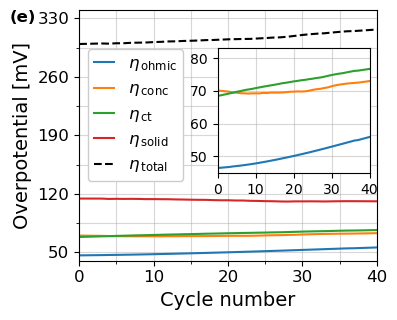

In [80]:
filename = "../raw_data/overpotentials.csv"

# --- read header ---
header = open(filename).readlines()[6].split(",")[1:]
header = [h[1:] for h in header]
header[-1] = header[-1][:-2]

df = pd.read_csv(filename, skiprows=8, sep=",", names=header)

# discharge branch
df = df[df["Cell current"] < -0.4]

# Savitzky-Golay smoothing params
f1 = 8
f2 = 1

g = df.groupby("Number of cycles")
cycles = g.size().index.to_numpy()
x = cycles + 0

# To reduce the high frequency noise stemming from the sampling rate of the simulation
def smooth(y):
    y = np.asarray(y, dtype=float)
    if len(y) <= f1:
        return y
    return scipy.signal.savgol_filter(y, f1, f2)

# components (mV)
eta_ohm_el = smooth(1000.0 * np.abs(g["overpot_electrolyte_ohmic"].mean().to_numpy()))
eta_conc   = smooth(1000.0 * np.abs(g["overpot_electrolyte_concentration"].mean().to_numpy()))
eta_ct     = smooth(1000.0 * np.abs(g["overpot_ct"].mean().to_numpy()))
eta_rest   = smooth(1000.0 * np.abs(g["overpot_rest"].mean().to_numpy()))

# total (mV)
eta_total  = smooth(1000.0 * np.abs((g["Cell potential"].mean() - g["equilibrium_pot"].mean()).to_numpy()))

fig, ax = plt.subplots(figsize=(4.2, 3.36))

# --- main plot: all lines on one axis ---
ax.plot(x, eta_ohm_el, label=r"$\eta_{\, \text{ohmic}}$")
ax.plot(x, eta_conc,   label=r"$\eta_{\,\text{conc}}$")
ax.plot(x, eta_ct,     label=r"$\eta_{\,\text{ct}}$")
ax.plot(x, eta_rest,   label=r"$\eta_{\, \text{solid}}$")
ax.plot(x, eta_total,  label=r"$\eta_{\, \text{total}}$", linestyle="--", color="k")

ax.grid(alpha=0.5)
ax.set_ylabel("Overpotential [mV]")
ax.set_xlabel("Cycle number")

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.0, 0.58),   # move legend upward a little
    framealpha=1,
    fontsize="medium",
    handlelength=1.2,
)

ax.set_yticks(np.arange(50, 330.1, 70))
ax.set_xticks(np.arange(0, 40.1, 10))
ax.set_xlim(0, df["Number of cycles"].max() + 0)
ax.set_ylim(40, 340)
ax.grid(which="minor", alpha=0.5)
ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))

numbering = (-9.3, "(e)")
if numbering != None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

plt.tight_layout()

# --- inset: everything except total ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="center right",
    bbox_to_anchor=(0.0, 0.1, 1.02, 1.0),   # move inset upward a bit
    bbox_transform=ax.transAxes,
    borderpad=0.8,
)
axins.plot(x, eta_ohm_el)
axins.plot(x, eta_conc)
axins.plot(x, eta_ct)
axins.plot(x, eta_rest)
axins.set_xticks(np.arange(0,40.1,10))

axins.grid(alpha=0.5)
axins.set_xlim(ax.get_xlim())

# optional: tighten inset y-limits to the components (so they fill the inset nicely)
y_comp = np.concatenate([eta_ohm_el, eta_conc, eta_ct])
pad = 0.05 * (y_comp.max() - y_comp.min() if y_comp.max() > y_comp.min() else 1.0)
axins.set_ylim(y_comp.min() - pad, y_comp.max() + pad +5)

# keep inset clean
axins.tick_params(labelsize=10)
axins.set_yticks(np.arange(50, 85.1, 10))

plt.savefig("../plots/overpotential_plot_1C_single_axis_with_inset.png", dpi=500)


In [82]:
print("Total increase in overpotential from first to last cycle: " + str(np.round(eta_total[-1] - eta_total[0], 1)) + "mV")

Total increase in overpotential from first to last cycle: 17.3mV


In [84]:
eta_total

array([299.30987862, 299.52309687, 299.73631512, 299.94953338,
       299.73996951, 300.20285165, 300.27252796, 300.75347976,
       300.93182759, 301.125035  , 301.58551385, 301.90092272,
       302.38353851, 302.52241908, 302.9648682 , 303.18964065,
       303.50021491, 303.96808226, 304.13582183, 304.53557381,
       304.91628466, 305.11486505, 305.33111217, 305.42459163,
       305.94698965, 306.3850479 , 306.98813308, 307.27256356,
       308.04434592, 309.05678707, 310.14357478, 311.00896578,
       311.68107528, 312.19753961, 313.07639239, 313.84139037,
       314.54577865, 314.84707976, 315.44968199, 316.05228422,
       316.65488645])